In [75]:
import pandas as pd, numpy as np
import sys, os
import seaborn as sns
import matplotlib.pyplot as plt
try:
    CURRENT_FOLDER = os.path.dirname(__file__) # normal way
except NameError:
    CURRENT_FOLDER = globals()['_dh'][0] # jupyter notebook way
sys.path.append(os.path.join(CURRENT_FOLDER, "..", "..", "benchmark"))

import benchmark_one

from IPython.display import display

In [37]:
INCREMENTAL_ALGOS = {"CNNR", "CkNNR"}
BEST_STATE_ALGOS = {"EnergyCompress", "CNNR", "CkNNR"}
best_states = dict()

algo = "EnergyCompress"
cb_learners = set()
for dataset in set(benchmark_one.DATASETS):
    try:
        for classifier in set(benchmark_one.CLASSIFIERS):  
            try:
                sys.argv = [""] + [dataset] + ["-a", algo] + ["-c", classifier]
                args = benchmark_one.parse_args()
                results = benchmark_one.load_results(args=args)
                df = pd.DataFrame.from_records(results["records"])
                #first_model = df.sort_values("CB_size", ascending=algo in INCREMENTAL_ALGOS).groupby("fold").head(1)
                #max_model = df.sort_values("CB_size", ascending=False).groupby("fold").head(1)
                #best_model["compression_rate"] = 1. - (best_model["CB_size"].astype(float) / results["args"]["size_S"])
                if algo in BEST_STATE_ALGOS:
                    best_model = df.sort_values("test_accuracy", ascending=False).groupby("fold").head(1)
                else:
                    best_model = df[df["step"]==1].copy()
                print(sys.argv, len(best_model[["step", "test_accuracy"]]))
                #print(best_model[["step", "test_accuracy"]])

                best_model["compression_rate"] = best_model["CB_size"].astype(float) / results["args"]["size_S"]
                best_model["CB"] = best_model.apply(
                    lambda row: results["models_cb"][f"fold {row['fold']}"][row["step"]],
                    axis=1)

                cb_learners.add(algo)

                # run other clf
                splits, y_values = benchmark_one.prep_dataset(args)

                # define a custom metric to account for the test set performance
                def test_ref_clf_prediction_summary(cb, X_ref, y_ref):
                    #torch.cuda.memory._dump_snapshot()
                    scores = {
                        "ref_"+k: v for k, v in benchmark_one.clf_prediction_summary(cb, X_ref, y_ref).items()
                    }
                    scores.update({
                        "test_"+k: v for k, v in benchmark_one.clf_prediction_summary(cb, X_test, y_test).items()
                    })
                    scores.update(args.model_pp)
                    #pbar3.set_postfix({"|CB|": len(cb), "ref. acc.": scores['ref_accuracy'], "test acc.": scores['test_accuracy']})
                    return scores
                
                for classifier_other in set(benchmark_one.CLASSIFIERS): 
                    best_model_ = best_model.copy()
                    if classifier_other != classifier:
                        for split_id, split in enumerate(splits):
                            (X_train, y_train) = split["train"]
                            (X_ref, y_ref) = split["ref"]
                            (X_test, y_test) = split["test"]
                            unique, counts = np.unique(y_test, return_counts=True)

                            # source_model CB
                            idx = best_model[best_model["fold"] == split_id].index[0]
                            X_train, y_train = best_model.loc[idx, "CB"]

                            # create the model
                            if classifier_other in benchmark_one.CLASSIFIERS.keys():
                                args.classifier = classifier_other
                                model = benchmark_one.CLASSIFIERS[classifier_other](benchmark_one.euclidean_sim, benchmark_one.class_equality_sim, args)
                            else: raise ValueError("Unsupported classifier")

                            # fit on the CB
                            try:
                                model.fit(X_train, y_train)
                            
                                # get performance
                                perf = test_ref_clf_prediction_summary(model, X_ref, y_ref)
                                for k, v in perf.items():
                                    best_model_.at[idx, k] = v
                            except ValueError as e: 
                                # if there is a fit error, fill with empty values
                                print(f"failed transfer of {classifier} onto {classifier_other} for dataset {dataset}")
                                if "The number of classes has to be greater than one; got 1 class" in str(e):
                                    for k in best_model_.columns:
                                        if k.startswith("ref_") or k.startswith("test_"):
                                            best_model_.at[idx, k] = None
                                else: raise e
                    best_states[(args.dataset_name, args.algo, classifier, classifier_other)] = best_model_
            except (FileNotFoundError) as e:
                pass
    except (FileNotFoundError, ValueError) as e:
        print(dataset)
        pass


['', 'kaggle+teaching+assistant+evaluation', '-a', 'EnergyCompress', '-c', 'SVM-rbf'] 10
['', 'kaggle+teaching+assistant+evaluation', '-a', 'EnergyCompress', '-c', 'SVM-linear'] 10
['', 'kaggle+teaching+assistant+evaluation', '-a', 'EnergyCompress', '-c', 'kNN'] 10
['', 'kaggle+teaching+assistant+evaluation', '-a', 'EnergyCompress', '-c', 'CtCoAT'] 10
['', 'kaggle+teaching+assistant+evaluation', '-a', 'EnergyCompress', '-c', 'CoAT'] 10
['', 'kaggle+teaching+assistant+evaluation', '-a', 'EnergyCompress', '-c', 'SVM-poly'] 10
['', 'iris', '-a', 'EnergyCompress', '-c', 'SVM-rbf'] 10
['', 'iris', '-a', 'EnergyCompress', '-c', 'SVM-linear'] 10
['', 'iris', '-a', 'EnergyCompress', '-c', 'kNN'] 10
['', 'iris', '-a', 'EnergyCompress', '-c', 'CtCoAT'] 10
['', 'iris', '-a', 'EnergyCompress', '-c', 'CoAT'] 10
['', 'iris', '-a', 'EnergyCompress', '-c', 'SVM-poly'] 10
['', 'heart+disease', '-a', 'EnergyCompress', '-c', 'SVM-rbf'] 10
['', 'heart+disease', '-a', 'EnergyCompress', '-c', 'SVM-linear'] 

In [39]:

best_states_df = pd.concat(best_states, axis=0).sort_index(level=0)
non_best_state_results_mask = best_states_df.index.to_series().apply(lambda x: x[2] not in BEST_STATE_ALGOS)
failed_runs_mask = non_best_state_results_mask & (best_states_df["compression_rate"] == 1)
failed_runs = best_states_df[failed_runs_mask]

# "dataset","algo","clf_fit","clf_pred","fold_"
print("involved datasets")
print(failed_runs.index.to_frame()[0].value_counts())
print("involved compression algos")
print(failed_runs.index.to_frame()[1].value_counts())
print("involved compression clf")
print(failed_runs.index.to_frame()[2].value_counts())
print("involved prediction clf")
print(failed_runs.index.to_frame()[3].value_counts())


best_states_df_no_fails = best_states_df[~failed_runs_mask]
complete = (best_states_df_no_fails.index.to_frame()[[0,1,2]].aggregate(tuple, axis=1).value_counts() == 10)
complete_list = complete.index.to_list()
complete_mask = best_states_df_no_fails.index.to_frame()[[0,1,2]].aggregate(tuple, axis=1).apply(lambda x: x in complete_list)
#best_states_df_no_fails.groupby(best_states_df_no_fails.index.to_frame()[[0,1,2]].aggregate(tuple, axis=1))
best_states_df_no_fails_complete = best_states_df_no_fails[complete_mask]
best_states_df_no_fails_complete = best_states_df_no_fails_complete.reset_index(names=["dataset","algo","clf_fit","clf_pred","fold_"])
best_states_df_no_fails_complete.index = pd.MultiIndex.from_frame(best_states_df_no_fails_complete[["dataset","algo","clf_fit","clf_pred","fold"]])

os.makedirs("v0.2", exist_ok=True)
best_states_df.to_pickle("v0.2/conf_matrix_results")
best_states_df_no_fails_complete.to_pickle("v0.2/conf_matrix_results_filtered")

involved datasets
Zoo                                     102
Breast Cancer Wisconsin Diagnostic       96
Credit Approval                          84
Ionosphere                               84
Iris                                     78
Balance Scale                            78
Kaggle Pima Indian Diabetes              72
Lung Cancer                              66
Dermatology                              60
Wine                                     54
Heart Disease                            42
Hepatitis                                42
Breast Cancer Wisconsin Prognostic       42
Glass Identification                     36
Haberman S Survival                      24
Kaggle Teaching Assistant Evaluation     24
Lenses                                   12
Liver Disorders                          12
Name: 0, dtype: int64
involved compression algos
EnergyCompress    1008
Name: 1, dtype: int64
involved compression clf
SVM-rbf       282
SVM-linear    270
SVM-poly      258
kNN           144

In [76]:

best_states_df = pd.read_pickle("v0.2/conf_matrix_results")
best_states_df_no_fails_complete = pd.read_pickle("v0.2/conf_matrix_results_filtered")

In [5]:
best_states_df_no_fails_complete.columns

Index(['dataset', 'classifier', 'algo_fit', 'algo_pred', 'fold_',
       'ref_gold_labels', 'ref_pred_probas', 'ref_pred_labels', 'ref_accuracy',
       'ref_per_class_f1', 'ref_per_class_precision', 'ref_per_class_recall',
       'ref_per_class_support', 'ref_weighted_f1', 'ref_weighted_precision',
       'ref_weighted_recall', 'ref_macro_f1', 'ref_macro_precision',
       'ref_macro_recall', 'ref_micro_f1', 'ref_micro_precision',
       'ref_micro_recall', 'ref_MCE_loss_functionals', 'ref_MCE_loss',
       'ref_hinge_loss_loss_functionals', 'ref_hinge_loss', 'test_gold_labels',
       'test_pred_probas', 'test_pred_labels', 'Accuracy', 'test_per_class_f1',
       'test_per_class_precision', 'test_per_class_recall',
       'test_per_class_support', 'test_weighted_f1', 'test_weighted_precision',
       'test_weighted_recall', 'test_macro_f1', 'test_macro_precision',
       'test_macro_recall', 'test_micro_f1', 'test_micro_precision',
       'test_micro_recall', 'test_MCE_loss_functiona

In [40]:
best_states_df_no_fails_complete

dataset  \
dataset       algo           clf_fit clf_pred fold                  
Balance Scale EnergyCompress CoAT    CoAT     0     Balance Scale   
                                              1     Balance Scale   
                                              2     Balance Scale   
                                              3     Balance Scale   
                                              4     Balance Scale   
...                                                           ...   
Zoo           EnergyCompress kNN     kNN      3               Zoo   
                                              4               Zoo   
                                              5               Zoo   
                                              7               Zoo   
                                              8               Zoo   

                                                              algo clf_fit  \
dataset       algo           clf_fit clf_pred fold                           
Balance Scale EnergyCompress CoAT    CoAT     0     EnergyCompress    CoAT   
                                              1     EnergyCompress    CoAT   
                                              2     EnergyCompress    CoAT   
                                              3     EnergyCompress    CoAT   
                                              4     EnergyCompress    CoAT   
...                                                            ...     ...   
Zoo           EnergyCompress kNN     kNN      3     EnergyCompress     kNN   
                                              4     EnergyCompress     kNN   
                                              5     EnergyCompress     kNN   
                                              7     EnergyCompress     kNN   
                                              8     EnergyCompress     kNN   

                                                   clf_pred  fold_  \
dataset       algo           clf_fit clf_pred fold                   
Balance Scale EnergyCompress CoAT    CoAT     0        CoAT     40   
                                              1        CoAT     88   
                                              2        CoAT    141   
                                              3        CoAT    178   
                                              4        CoAT    234   
...                                                     ...    ...   
Zoo           EnergyCompress kNN     kNN      3         kNN    155   
                                              4         kNN    225   
                                              5         kNN    254   
                                              7         kNN    365   
                                              8         kNN    411   

                                                                                      ref_gold_labels  \
dataset       algo           clf_fit clf_pred fold                                                      
Balance Scale EnergyCompress CoAT    CoAT     0     [1, 2, 0, 2, 1, 1, 2, 2, 1, 2, 1, 1, 1, 1, 1, ...   
                                              1     [2, 0, 2, 1, 2, 0, 2, 2, 2, 1, 2, 2, 1, 2, 1, ...   
                                              2     [1, 2, 0, 2, 1, 1, 1, 2, 1, 1, 1, 1, 2, 1, 0, ...   
                                              3     [1, 0, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 2, 2, ...   
                                              4     [1, 2, 2, 1, 2, 2, 2, 2, 1, 1, 1, 1, 2, 0, 1, ...   
...                                                                                               ...   
Zoo           EnergyCompress kNN     kNN      3     [0, 3, 2, 0, 6, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, ...   
                                              4     [2, 1, 5, 1, 3, 3, 0, 3, 4, 0, 0, 0, 3, 1, 1, ...   
                                              5     [3, 5, 1, 0, 6, 0, 0, 0, 0, 2, 0, 0, 0, 5, 3, ...   
                                              7     [6, 3, 0, 1, 3, 2, 0, 5, 0,

### For each dataset conf_matrix for energy_compress

In [78]:
CMAP = "viridis"
YLABEL = "Model used to select the cases with EnergyCompress"
XLABEL = "Model used for prediction"
VMIN = 0.5
VMAX = 1.

/home/emarquer/anaconda3/envs/meat/lib/python3.10/site-packages/pandas/core/array_algos/replace.py:86: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  op = lambda x: operator.eq(x, b)


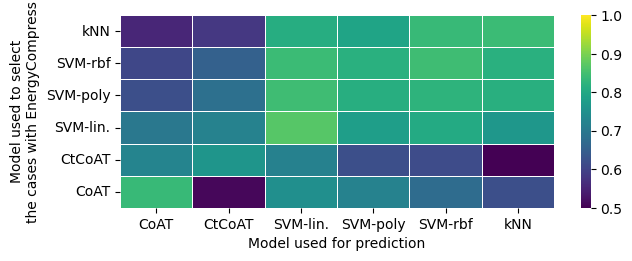

<Figure size 640x480 with 0 Axes>

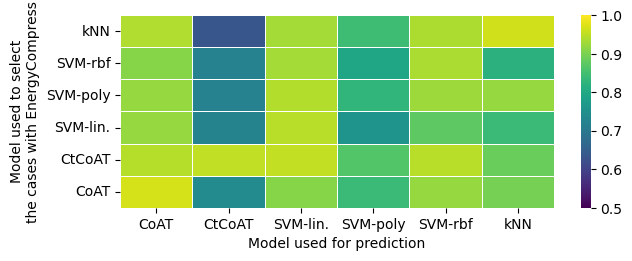

<Figure size 640x480 with 0 Axes>

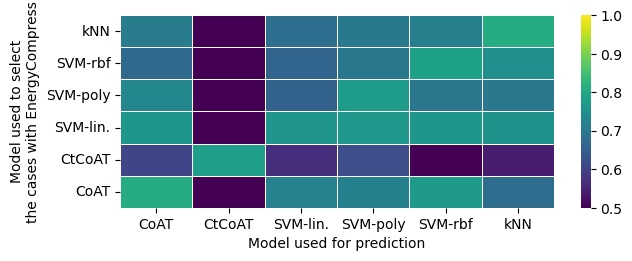

<Figure size 640x480 with 0 Axes>

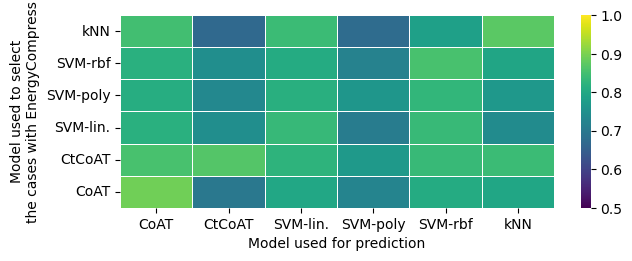

<Figure size 640x480 with 0 Axes>

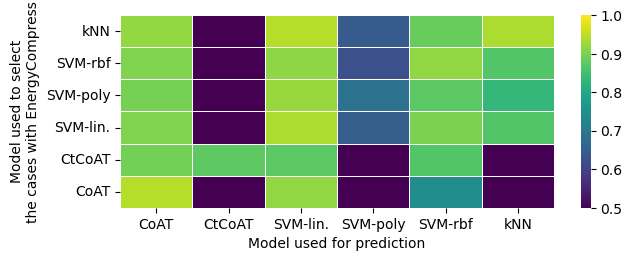

<Figure size 640x480 with 0 Axes>

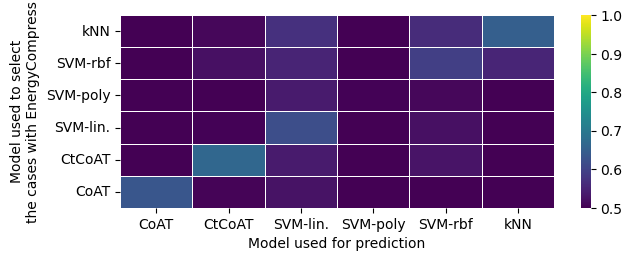

<Figure size 640x480 with 0 Axes>

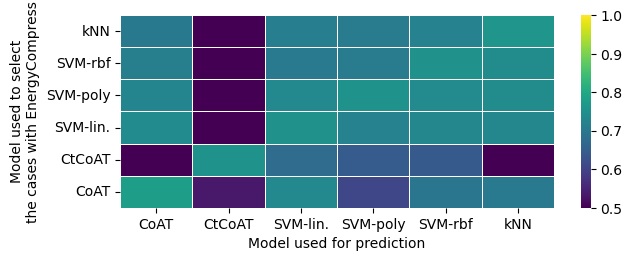

<Figure size 640x480 with 0 Axes>

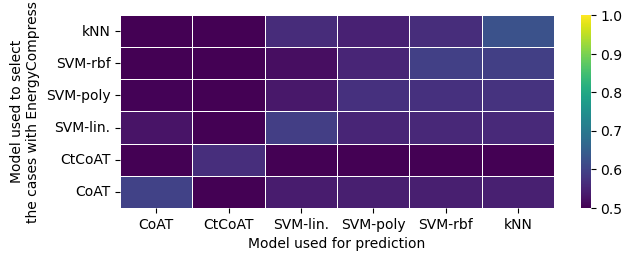

<Figure size 640x480 with 0 Axes>

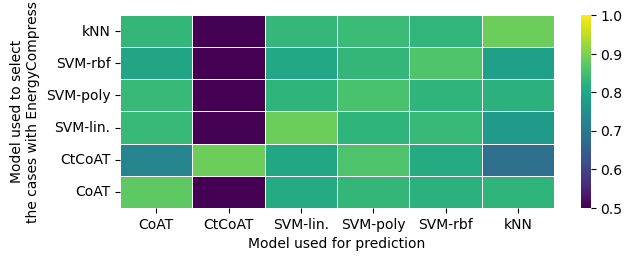

<Figure size 640x480 with 0 Axes>

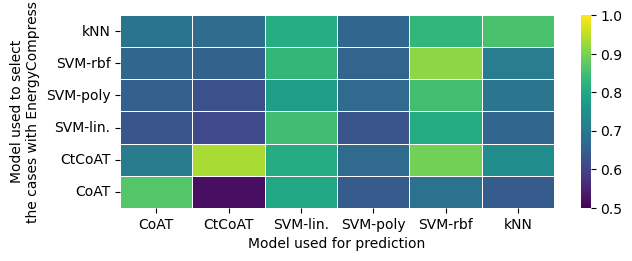

<Figure size 640x480 with 0 Axes>

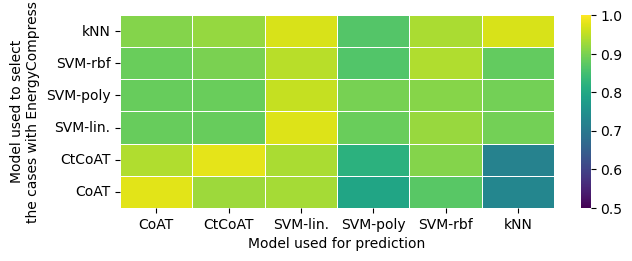

<Figure size 640x480 with 0 Axes>

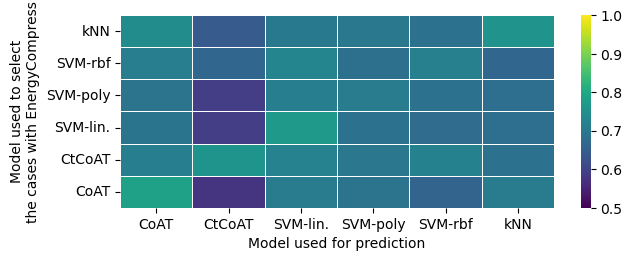

<Figure size 640x480 with 0 Axes>

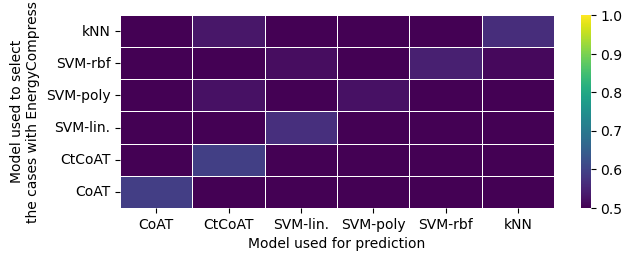

<Figure size 640x480 with 0 Axes>

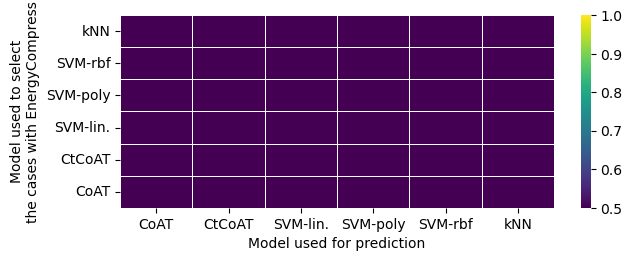

<Figure size 640x480 with 0 Axes>

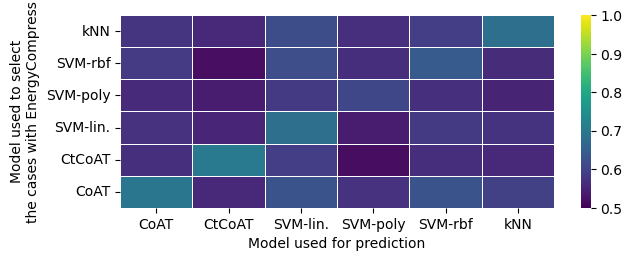

<Figure size 640x480 with 0 Axes>

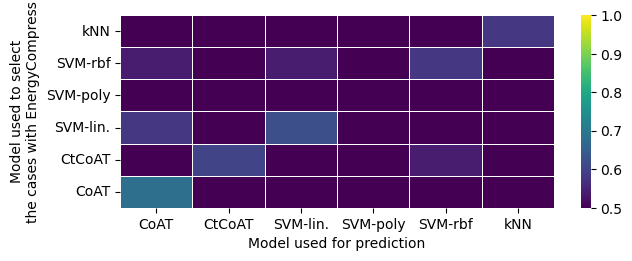

<Figure size 640x480 with 0 Axes>

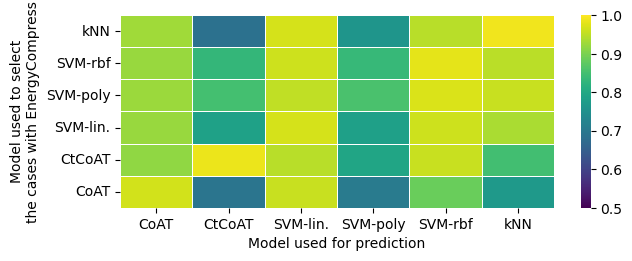

<Figure size 640x480 with 0 Axes>

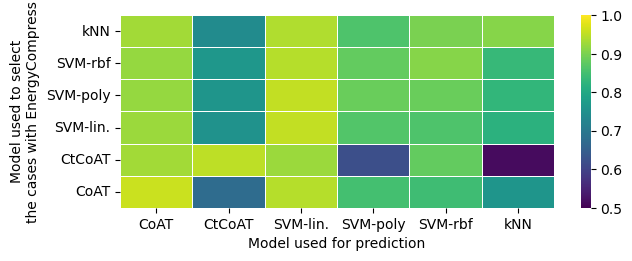

<Figure size 640x480 with 0 Axes>

In [113]:

best_states_df = pd.concat(best_states, axis=0).sort_index(level=0)
dfds = best_states_df.reset_index(names=["dataset","compress_algo","clf_fit","clf_pred","fold_"])
#dfds = best_states_df_no_fails_complete.reset_indexµ(drop="fold")
dfds = dfds.rename({"test_accuracy": "Accuracy", "CB_size": "|CB|"}, axis=1)
dfds = dfds.replace({"SVM-linear": "SVM-lin."})

YLABEL_ = "Model used to select\nthe cases with EnergyCompress"
for dataset in dfds["dataset"].unique():
    
    dfd = dfds[dfds["dataset"]==dataset]
    dfd_mean = dfd.groupby(["clf_fit", "clf_pred"])["Accuracy"]
    dfd_mean = dfd_mean.mean()
    dfd_mean = dfd_mean.reset_index()

    dfd.iloc[0]["model"]

    plt.figure(figsize = (7,2.5))
    ax = sns.heatmap(
        dfd_mean.pivot(index="clf_fit", columns="clf_pred", values="Accuracy"), cmap=CMAP, vmax=VMAX, vmin=VMIN,
        #square=True, 
        linewidth=.5, 
        )
    ax.invert_yaxis()
    #plt.title(f"{dataset} accuracy mean heatmap")
    plt.ylabel(YLABEL_)
    plt.xlabel(XLABEL)
    #plt.xticks(rotation=25, ha='right')
    plt.xticks(rotation=0)
    os.makedirs(f"v0.2/plots/{dataset}", exist_ok=True)
    plt.savefig(f"v0.2/plots/{dataset}/acc-mean.png", bbox_inches="tight")
    plt.savefig(f"v0.2/plots/{dataset}/acc-mean.pdf", bbox_inches="tight")
    plt.show()
    plt.clf()
    

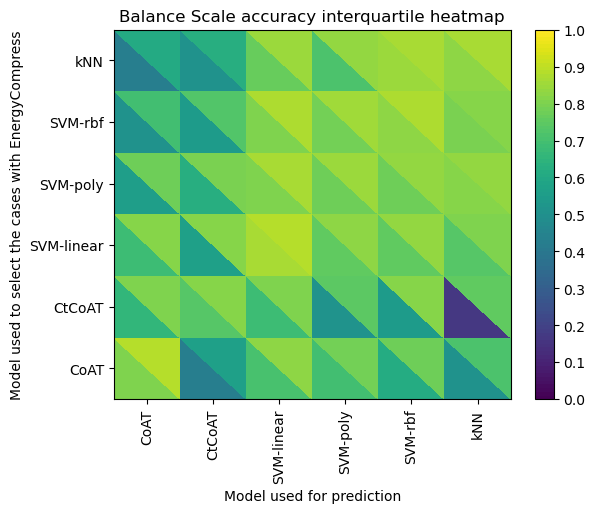

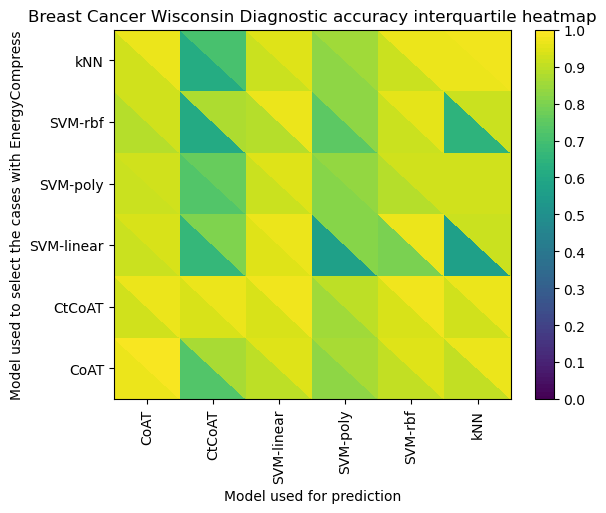

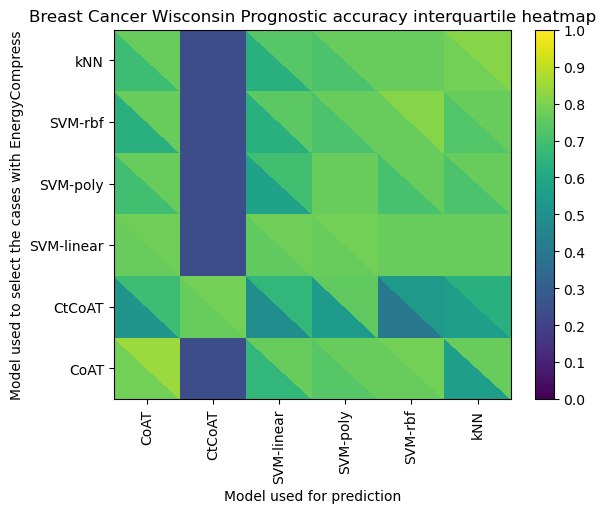

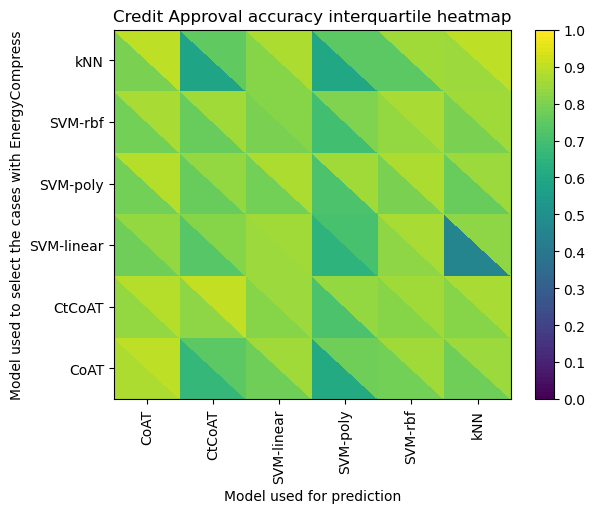

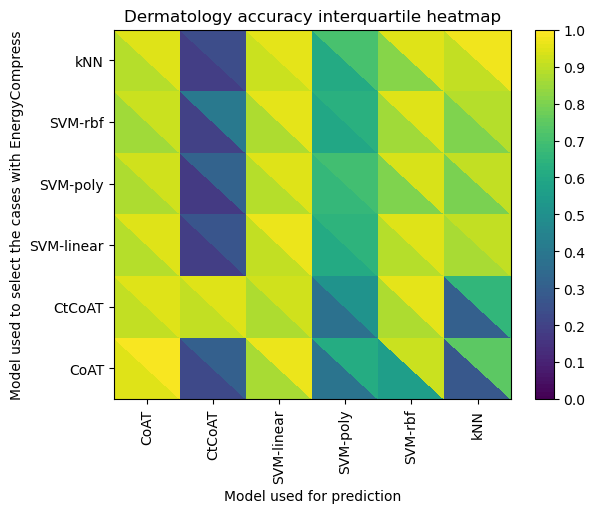

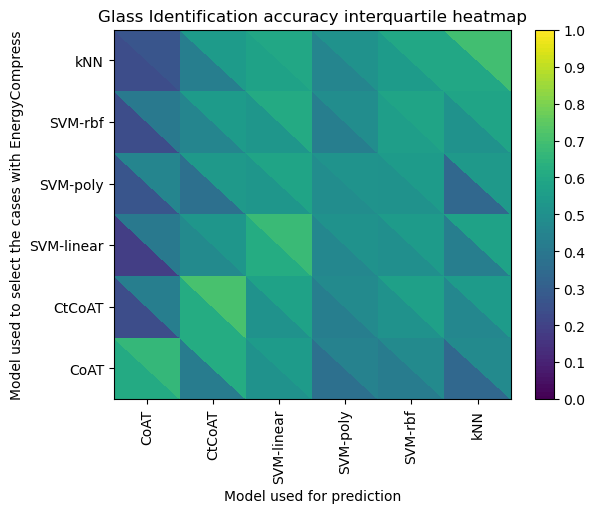

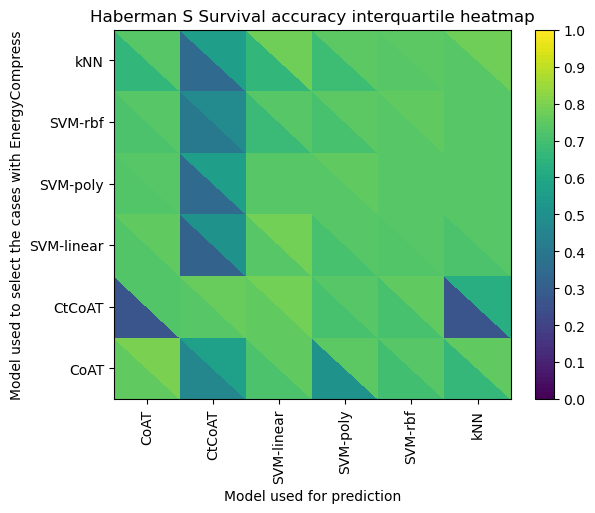

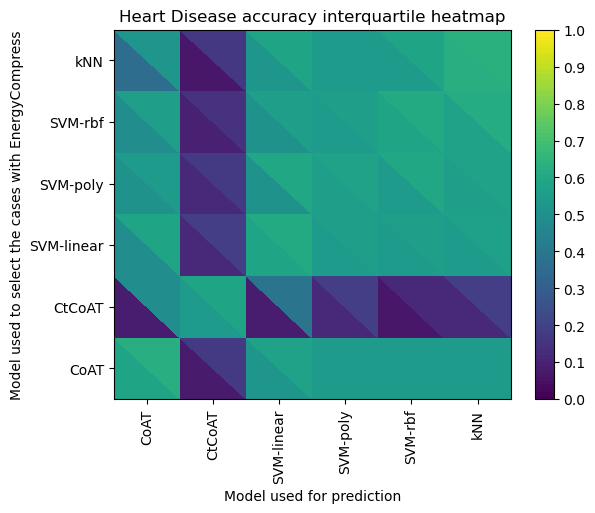

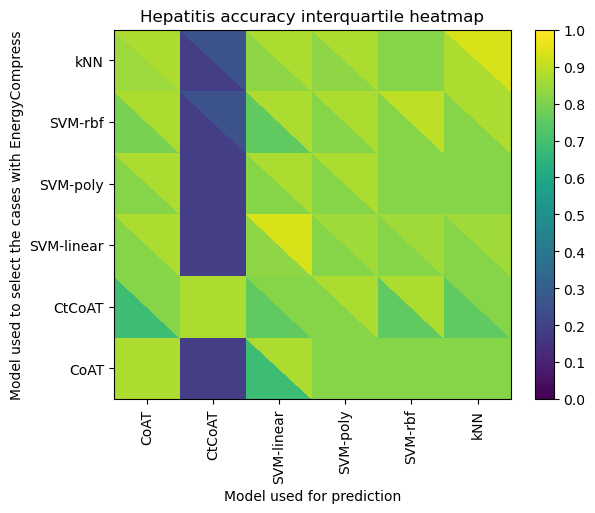

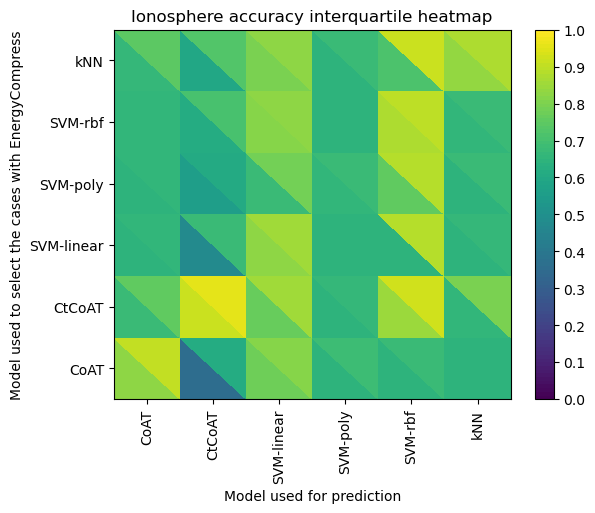

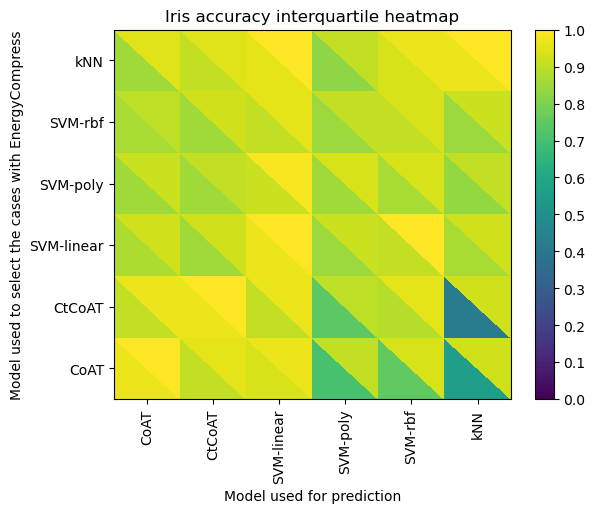

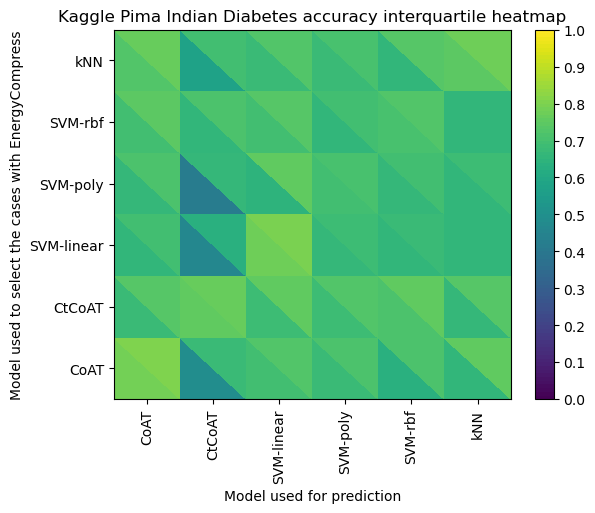

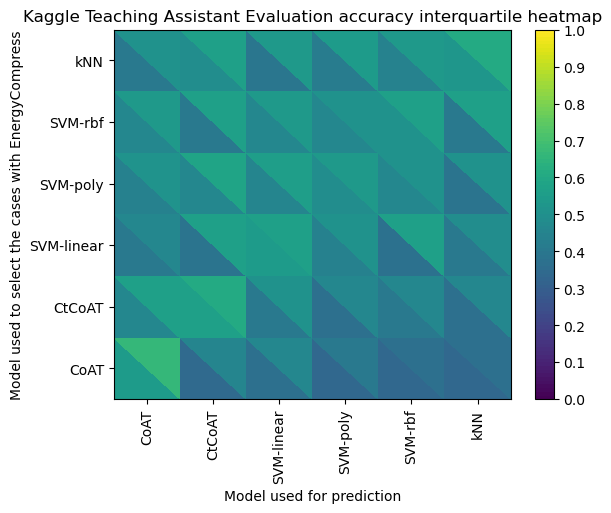

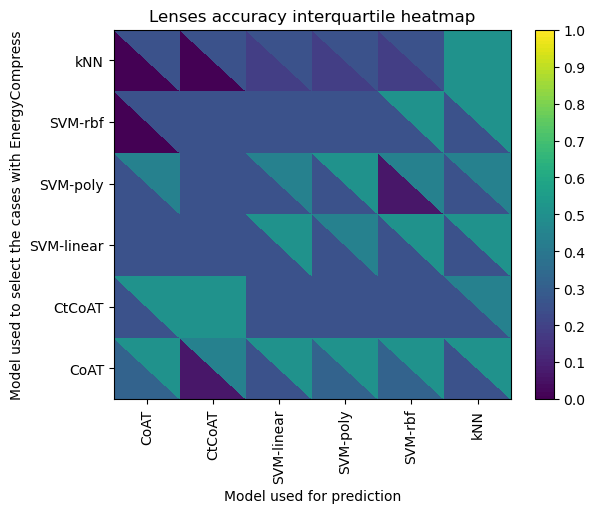

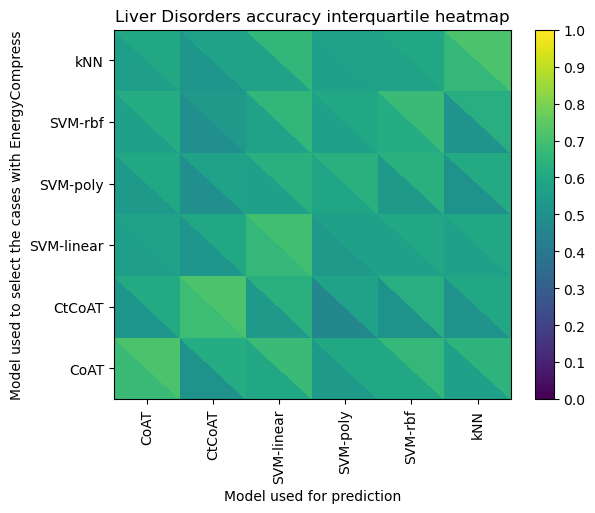

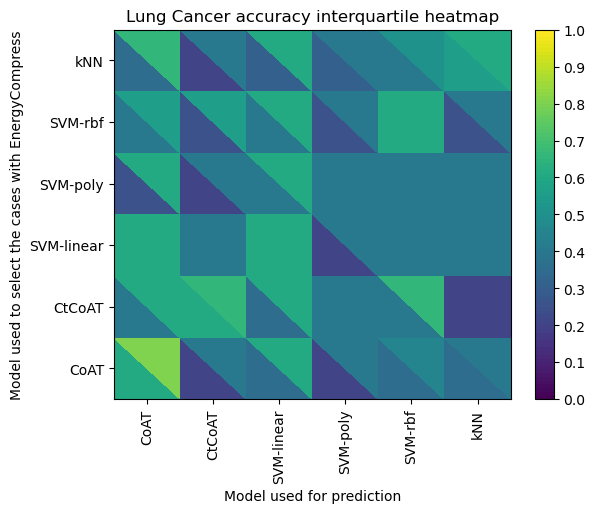

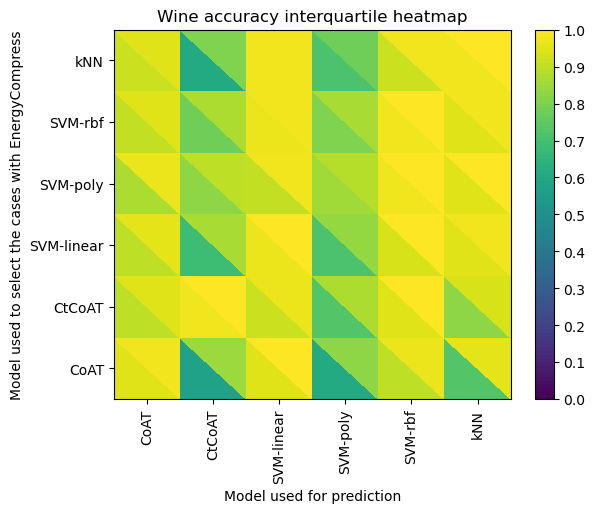

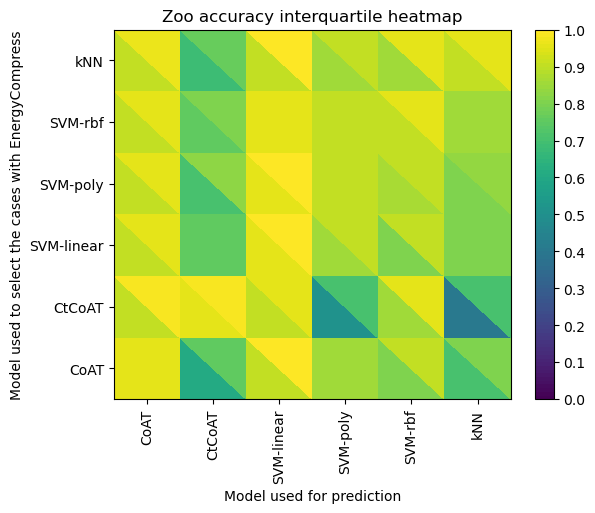

In [82]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation

def quartile_heatmap(df, y_var, x_var, value_var):
    values: pd.DataFrame = df.groupby([y_var, x_var])[value_var].describe().reset_index()
    #print(values)
    mean: pd.DataFrame = values.pivot(index=y_var, columns=x_var, values="mean")
    q1: pd.DataFrame = values.pivot(index=y_var, columns=x_var, values="25%")
    q2: pd.DataFrame = values.pivot(index=y_var, columns=x_var, values="50%")
    q3: pd.DataFrame = values.pivot(index=y_var, columns=x_var, values="75%")

    M = len(mean.columns)
    N = len(mean.index)
    x = np.arange(M + 1)
    y = np.arange(N + 1)
    xs, ys = np.meshgrid(x, y)
    

    triangles1 = [(i + j*(M+1), i+1 + j*(M+1), i + (j+1)*(M+1)) for j in range(N) for i in range(M)]
    triangles2 = [(i+1 + j*(M+1), i+1 + (j+1)*(M+1), i + (j+1)*(M+1)) for j in range(N) for i in range(M)]
    triang1 = Triangulation(xs.ravel()-0.5, ys.ravel()-0.5, triangles1)
    triang2 = Triangulation(xs.ravel()-0.5, ys.ravel()-0.5, triangles2)
    img1 = plt.tripcolor(triang1, q1.to_numpy().ravel(), cmap=plt.get_cmap(CMAP, 100), vmax=1, vmin=0)
    img2 = plt.tripcolor(triang2, q3.to_numpy().ravel(), cmap=plt.get_cmap(CMAP, 100), vmax=1, vmin=0)

    #plt.colorbar(img2, ticks=range(10), pad=-0.05)
    plt.colorbar(img1, ticks=[a/10. for a in range(11)])
    plt.xlim(x[0]-0.5, x[-1]-0.5)
    plt.ylim(y[0]-0.5, y[-1]-0.5)
    plt.xticks(x[:-1], rotation=90,labels = mean.columns)
    plt.yticks(y[:-1],labels=mean.index)




best_states_df = pd.concat(best_states, axis=0).sort_index(level=0)
dfds = best_states_df.reset_index(names=["dataset","compress_algo","clf_fit","clf_pred"],drop="fold")
dfds = best_states_df_no_fails_complete.reset_index(drop="fold")
dfds = dfds.rename({"test_accuracy": "Accuracy", "CB_size": "|CB|"}, axis=1)

for dataset in dfds["dataset"].unique():
    
    dfd = dfds[dfds["dataset"]==dataset]

    quartile_heatmap(dfd, "clf_fit", "clf_pred", "Accuracy")
    plt.title(f"{dataset} accuracy interquartile heatmap")
    plt.ylabel(YLABEL)
    plt.xlabel(XLABEL)
    os.makedirs(f"v0.2/plots/{dataset}", exist_ok=True)
    plt.savefig(f"v0.2/plots/{dataset}/acc-interquartile.png", bbox_inches="tight")
    plt.show()

In [96]:
from scipy.stats import ttest_rel
pairs = dict()
dataset = "Iris"
dfd = dfds[dfds["dataset"]==dataset]
for clf_fit in dfd["clf_fit"].unique():
    for clf_pred in dfd["clf_fit"].unique():
        if clf_pred!=clf_fit:
            acc_fit = dfd[(dfd["clf_fit"] == clf_fit) & (dfd["clf_pred"] == clf_fit)]["Accuracy"]
            acc_pred = dfd[(dfd["clf_fit"] == clf_fit) & (dfd["clf_pred"] == clf_pred)]["Accuracy"]
            #print(acc_fit, acc_pred)
            pairs[(clf_fit, clf_pred)] = (ttest_rel(acc_fit, acc_pred).pvalue)
    
# ttest_rel()
np.quantile(list(pairs.values()), [0, 0.1, 0.25, 0.5, 0.75, 0.9, 1]).tolist(), np.mean(list(pairs.values())), np.std(list(pairs.values()))

([0.0005877161111330688,
  0.002902647987704589,
  0.009942317753884919,
  0.030865800360174424,
  0.1510557138665823,
  0.6295490183399626,
  0.8382299954533016],
 0.16563403069646082,
 0.2516515376521837)

In [97]:
pairs

{('CoAT', 'CtCoAT'): 0.03407636163418568,
 ('CoAT', 'SVM-linear'): 0.10907771593031607,
 ('CoAT', 'SVM-poly'): 0.002408500892683568,
 ('CoAT', 'SVM-rbf'): 0.034875610350342055,
 ('CoAT', 'kNN'): 0.012571399393934654,
 ('CtCoAT', 'CoAT'): 0.012992786487757379,
 ('CtCoAT', 'SVM-linear'): 0.027655239086163165,
 ('CtCoAT', 'SVM-poly'): 0.0005877161111330688,
 ('CtCoAT', 'SVM-rbf'): 0.05270252208551391,
 ('CtCoAT', 'kNN'): 0.0216136426750991,
 ('SVM-linear', 'CoAT'): 0.0041047159800533225,
 ('SVM-linear', 'CtCoAT'): 0.006748438223748888,
 ('SVM-linear', 'SVM-poly'): 0.003405628297383272,
 ('SVM-linear', 'SVM-rbf'): 0.09251500555042752,
 ('SVM-linear', 'kNN'): 0.0029575532204847025,
 ('SVM-poly', 'CoAT'): 0.6890522264439654,
 ('SVM-poly', 'CtCoAT'): 0.8382299954533016,
 ('SVM-poly', 'SVM-linear'): 0.03746413165667986,
 ('SVM-poly', 'SVM-rbf'): 0.628576812417633,
 ('SVM-poly', 'kNN'): 0.4816178143121549,
 ('SVM-rbf', 'CoAT'): 0.011724811003954635,
 ('SVM-rbf', 'CtCoAT'): 0.2855909406452012,
 